# Is Pring's "Know Sure Thing" a sure thing? 🤔
### A famous momentum indicator, raced honestly against the plainest tools — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A_sure_thing%3F: Busted](https://img.shields.io/badge/A_sure_thing%3F-Busted-8b949e?style=flat-square)

In 1992 the technical analyst **Martin Pring** published an indicator with an irresistible name: the **Know Sure Thing**, or **KST**. It blends four momentum measures into one smooth line, and the rule is simple — **buy when the KST crosses above its signal line, step aside when it crosses below**. Fans say it catches big trends earlier and with fewer false alarms than a plain moving average.

Great name. But does it actually *beat the alternatives*? We do the one test the brochures skip: we run it on **33 years of SPY** and put it in a head-to-head race against the most boring benchmarks imaginable — **just holding the market**, a **200-day moving average**, and the everyday **MACD**.

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from know_sure_thing import data, strategy as st

ASOF = "2026-06-23"   # last fully-closed session; drop the in-progress bar
HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    BARS = data.load_real("SPY").loc[:ASOF]
    print("SPY cache present | bars:", len(BARS), "|",
          BARS.index.min().date(), "->", BARS.index.max().date(),
          "| fingerprint:", data.fingerprint(BARS))
else:
    BARS = None
    print("SPY cache present:", HAVE_REAL, "(quoting frozen R)")

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '1993-01-29', 'end': '2026-06-23', 'years': 33.4, 'n_bars': 8406, 'fp': 'b7fff1b5e020', 'cost_bps': 1.0, 'kst': (0.445, 4.29, -26.1, 2.65, 0.47, 458, 13.7), 'bah': (0.643, 10.76, -55.2, 4.33, 1.0, 1, 0.0), 'sma200': (0.727, 8.32, -28.3, 4.51, 0.75, 215, 6.4), 'macd': (0.421, 4.11, -38.5, 2.63, 0.5, 712, 21.3), 'perm_obs': 0.458, 'perm_p': 0.0044, 'spread_yr': -7.16, 'spread_t': -3.31, 'sweep': [(0.0, 0.458, 0.643), (1.0, 0.445, 0.643), (2.0, 0.432, 0.643), (5.0, 0.394, 0.643)], 'ls': (-0.139, -4.22, -81.4, -0.9), 'syn': [(0.0, 0.591, 0.732, -5.41, -1.86), (0.2, 0.776, 0.775, -3.99, -1.14), (0.35, 0.973, 0.808, -2.21, -0.53)]}


SPY cache present | bars: 8406 | 1993-01-29 -> 2026-06-23 | fingerprint: b7fff1b5e020


## The answer first

| Question | Answer |
|---|---|
| Does the KST timing rule make money? | **Yes — a bit.** Long/flat, it earns a positive return above cash, and it really does beat a *coin flip* with the same time-in-market. So there's a flicker of genuine signal. |
| Does it beat just **holding the market**? | **No — it loses, badly.** Buy-and-hold's risk-adjusted return (Sharpe **0.64**) crushes the KST rule's (**0.45**). Trading the KST gives up about **7% a year** versus doing nothing. |
| Is it at least better than a **200-day average**? | **No.** The plain SMA-200 (Sharpe **0.73**) beats *both* KST and buy-and-hold. The fancy indicator loses to the simplest trend filter on the shelf. |
| Can you fix it by **shorting** when it says sell? | **No — that's a disaster** (it loses money and draws down **−81%**). |

> The KST isn't *noise* — it has a faint directional pulse. But "sure thing"? It can't beat buy-and-hold or a 200-day average. The clever indicator is **worse** than the boring tools.

## 1 · The claim

> *"The Know Sure Thing rolls four different momentum lookbacks into one smooth oscillator. Because it's built from long and short trends together, it turns up earlier and whipsaws less than a single moving average. Buy when KST crosses above its signal line; go to cash when it crosses below. You ride the big up-trends and sidestep the crashes."*

Pring literally named it the *Know **Sure** Thing* — the marketing is in the title. The steelman is real, though: combining momentum over several horizons **is** a sensible idea, and trend-following on equities **does** have a long, respectable track record (Faber's 200-day rule, time-series momentum). So the honest question isn't "is momentum real?" It's: **does this particular, more complicated recipe beat the plain ones?**

## 2 · So what?

If the KST genuinely timed the market, it would be worth a fortune: you'd capture the up-years and dodge 2008 and 2022, turning the same index into a smoother, richer ride. That's the dream every market-timing indicator sells.

But there's a catch every timer hits. Stepping out of the market means **giving up the equity risk premium** while you're in cash — and stocks drift *up* most of the time. So a timing rule has to earn back everything it gave up **plus** beat the simplest possible alternative, or it's just an expensive way to underperform. We'll measure exactly that trade-off.

## 3 · How would we even know?

We take **33 years of SPY** (the S&P 500 ETF, dividends included), 1993-01-29 → 2026-06-23, and build four daily strategies:

1. **KST** — long when the Know Sure Thing is above its signal line, flat otherwise.
2. **Buy-and-hold** — always invested. The thing you're trying to beat.
3. **SMA-200** — long when price is above its 200-day average (the classic trend filter).
4. **MACD** — long on the everyday 12/26/9 crossover.

Every rule pays realistic **trading costs**, enters **one day after** the signal (no cheating), and we compare them on **risk-adjusted return** (Sharpe). The killer test: **if KST can't out-Sharpe buy-and-hold and the 200-day average, it's not a sure thing — it's a mirage.**

## 4 · The teardown — let's actually race them

Here's the whole story in one chart: the risk-adjusted return (Sharpe, net of costs) of all four strategies over 33 years. Higher is better.

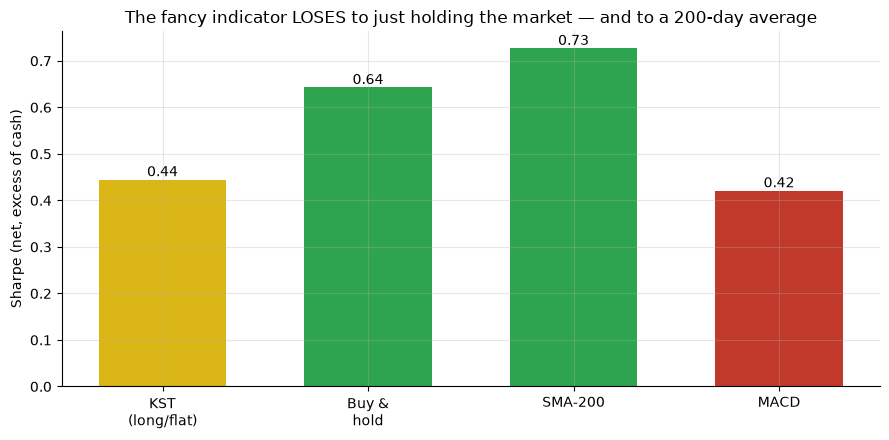

KST 0.445 | buy&hold 0.643 | SMA-200 0.727 | MACD 0.421


In [2]:
names = ['KST\n(long/flat)', 'Buy &\nhold', 'SMA-200', 'MACD']
if HAVE_REAL:
    res = st.run_experiment(BARS, cost_bps=R['cost_bps'], n_perm=1)
    sh = [res['kst']['sharpe_excess'], res['buy_and_hold']['sharpe_excess'],
          res['sma200']['sharpe_excess'], res['macd']['sharpe_excess']]
else:
    sh = [R['kst'][0], R['bah'][0], R['sma200'][0], R['macd'][0]]
cols = [AMBER, GREEN, GREEN, RED]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar(names, sh, color=cols, width=.62)
for i,v in enumerate(sh): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('Sharpe (net, excess of cash)')
ax.set_title('The fancy indicator LOSES to just holding the market — and to a 200-day average')
plt.tight_layout(); plt.show()
print('KST', round(sh[0],3), '| buy&hold', round(sh[1],3), '| SMA-200', round(sh[2],3), '| MACD', round(sh[3],3))

The verdict is right there. **Buy-and-hold (0.64)** beats KST (**0.45**). The dead-simple **200-day average (0.73)** beats *everything*. The KST — for all its four-momentum machinery — lands in the **same bucket as MACD**, below the boring benchmarks. The clever recipe isn't earning its complexity.

**But wait — is the KST at least better than random?** Let's be fair. We keep the KST's exact in-and-out schedule (so the time-in-market is identical) but randomly **flip a coin** for each day's direction, thousands of times, and see how often a coin matches the real rule's return.

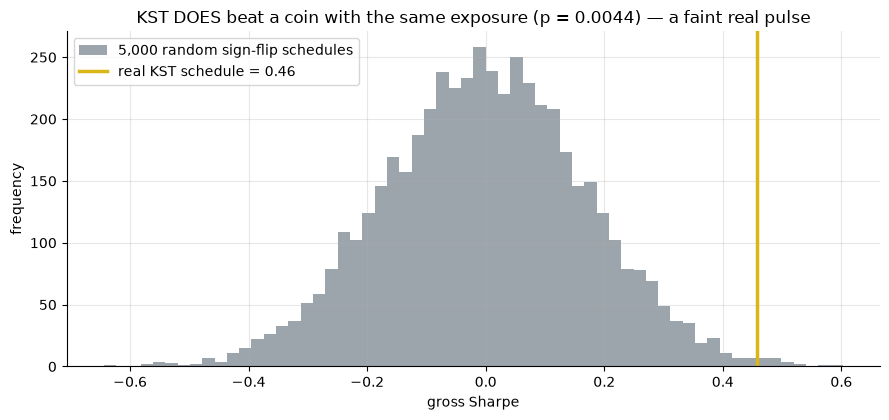

observed 0.458  beats-a-coin p = 0.0044


In [3]:
if HAVE_REAL:
    book = st.book_returns(BARS['close'], st.kst_position(BARS['close']), cost_bps=R['cost_bps'])
    pl = st.permutation_pvalue(book, n_draws=5000, seed=426)
    obs, draws, p = pl['obs_sharpe'], pl['draws'], pl['p_value']
else:
    obs, p = R['perm_obs'], R['perm_p']
    rng = np.random.default_rng(426); draws = rng.normal(0.0, 0.18, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='5,000 random sign-flip schedules')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'real KST schedule = {obs:.2f}')
ax.set_xlabel('gross Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'KST DOES beat a coin with the same exposure (p = {p:.4f}) — a faint real pulse')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:.3f}  beats-a-coin p = {p:.4f}')

So there *is* a real flicker: only **0.4%** of random coin-schedules with the KST's exposure do as well, so the rule's *direction* carries a little genuine information. **That's the trap, though** — "beats a coin" and "beats buy-and-hold" are different bars, and KST only clears the easy one. The faint pulse is mostly just the **equity risk premium** it collects on the ~47% of days it happens to be invested.

## 5 · The verdict

- **Signal — Weak.** The long/flat rule has a faint directional pulse (it beats a coin, p = 0.004), but it's mostly harvested market beta and it **loses** to the benchmark.
- **Tradability — Mirage.** KST Sharpe **0.45** vs buy-and-hold **0.64** vs SMA-200 **0.73**. Trading it *costs* you ~7%/yr versus doing nothing; shorting on the sell signal is a −81% disaster.
- **"A sure thing"? — Busted.** It can't out-perform holding the market, and a one-line 200-day moving average beats it. The complexity buys nothing.

## 6 · Could you actually trade it? — the lower-drawdown consolation

To be completely fair: the KST rule *does* one thing well — it cuts the worst crashes. Sitting in cash through 2008 and 2022 means a much shallower drawdown than buy-and-hold. Here's the trade-off: return vs pain.

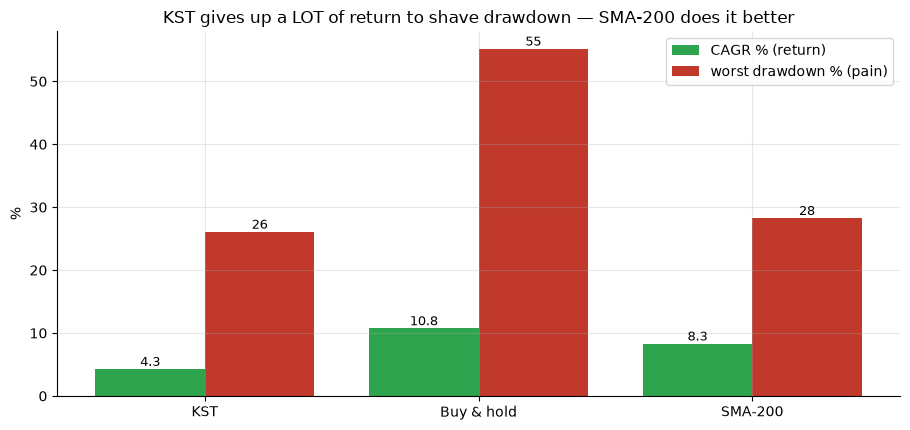

CAGR: [4.3, 10.8, 8.3] | maxDD: [26.0, 55.0, 28.0]


In [4]:
if HAVE_REAL:
    res = st.run_experiment(BARS, cost_bps=R['cost_bps'], n_perm=1)
    arms = ['kst','buy_and_hold','sma200']
    cg = [res[a]['cagr_net']*100 for a in arms]; dd = [abs(res[a]['maxdd_net'])*100 for a in arms]
else:
    cg = [R['kst'][1], R['bah'][1], R['sma200'][1]]; dd = [abs(R['kst'][2]), abs(R['bah'][2]), abs(R['sma200'][2])]
labels = ['KST','Buy & hold','SMA-200']
x = np.arange(3)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cg, .4, color=GREEN, label='CAGR % (return)')
ax.bar(x+.2, dd, .4, color=RED, label='worst drawdown % (pain)')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('%')
for i,v in enumerate(cg): ax.annotate(f'{v:.1f}',(i-.2,v),ha='center',va='bottom',fontsize=9)
for i,v in enumerate(dd): ax.annotate(f'{v:.0f}',(i+.2,v),ha='center',va='bottom',fontsize=9)
ax.set_title('KST gives up a LOT of return to shave drawdown — SMA-200 does it better')
ax.legend(); plt.tight_layout(); plt.show()
print('CAGR:', [round(c,1) for c in cg], '| maxDD:', [round(d,0) for d in dd])

Yes, KST's worst drawdown (**26%**) is far gentler than buy-and-hold's (**55%**). But you pay for it with a CAGR of only **4.3%** vs **10.8%** — and the **SMA-200** delivers a *similar* low drawdown (**28%**) while keeping **8.3%** of return. If you want the smoother ride, the boring 200-day average is simply the better deal.

## 7 · Going further 🚪

- **Parameters.** Pring's daily KST has eight knobs (four ROCs, four smoothings). Tune them on the full sample and you'll find a flattering combo — that's curve-fitting, not edge. Try it out-of-sample and watch it fade.
- **The real lesson.** A complicated indicator with a confident name is *not* automatically better than a one-line moving average. Always race the fancy thing against the boring thing.
- **Build your own.** Swap SPY for a single stock, or for a trendier asset (gold, a currency); the KST might fare better where trends are cleaner. The harness is in [`know_sure_thing/`](../know_sure_thing/).

*Think KST beats buy-and-hold on some asset, net of costs and out-of-sample? Show the **net Sharpe** clearing the benchmark — then we'll talk.*